In [55]:
device="cuda"

In [56]:
import numpy as np
import copy
from packboost.core import PackBoost
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import time

np.random.seed(42)
X = np.random.randint(0, 4, (100000, 20), dtype='i1')
Xval = np.random.randint(0, 4, (2000, 20), dtype='i1')
X_test = np.random.randint(0, 4, (500, 20), dtype='i1')

def make_y(X_):
    # Spread signal across many dimensions with small interaction terms
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        + 0.22 * X_[:, 2].astype('f4')
        + 0.010 * np.random.randn(len(X_)).astype('f4')
    )

y    = make_y(X)
yval = make_y(Xval)
y_test_true = make_y(X_test)

# Apply MinMaxScaler to scale y values to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()
yval_scaled = scaler.transform(yval.reshape(-1, 1)).ravel()
y_test_true_scaled = scaler.transform(y_test_true.reshape(-1, 1)).ravel()

# Bucketize into [0, 0.25, 0.5, 0.75, 1]
bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = [0.125, 0.375, 0.625, 0.875]  # Midpoints of each bucket

y = np.array(pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)
yval = np.array(pd.cut(yval_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)
y_test_true = np.array(pd.cut(y_test_true_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)

print(f"Preprocessed y - min: {y.min()}, max: {y.max()}")
print(f"Unique y values: {np.unique(y)}")

model = PackBoost(device=device)
start = time.time()
model.fit(
    X, y,
    Xv=Xval, Yv=yval,
    rounds=200,
    max_depth=8,
    nfolds=4,
    lr=1.0,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device,
    L2 = 10_000.0,
    min_child_weight= 200.0,
    min_split_gain= 0.0,
)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds")

Preprocessed y - min: 0.125, max: 0.875
Unique y values: [0.125 0.375 0.625 0.875]
Training completed in 0.37 seconds


## compare cpu vs gpu P

Pearson r : 0.9516
R²        : 0.9045


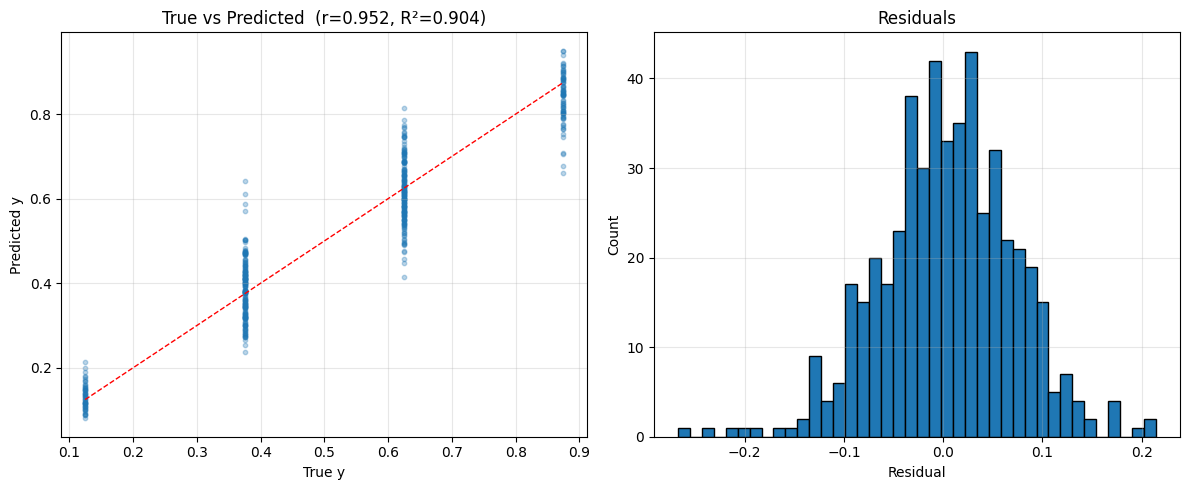

In [57]:
import matplotlib.pyplot as plt

preds = model.predict(X_test)/ (1 << 30)
corr = np.corrcoef(preds, y_test_true)[0, 1]
ss_res = np.sum((y_test_true - preds) ** 2)
ss_tot = np.sum((y_test_true - y_test_true.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f"Pearson r : {corr:.4f}")
print(f"R²        : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_true, preds, alpha=0.3, s=10)
lo, hi = y_test_true.min(), y_test_true.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_xlabel("True y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title(f"True vs Predicted  (r={corr:.3f}, R²={r2:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_test_true - preds, bins=40, edgecolor='black')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()